In [1015]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import percentileofscore
from scipy.stats import norm

In [1016]:
# Knobs to turn within a bin (X° look x Y° depression)
n = 1      # average number of data points in a potential subset (hits/mission)
s = 20      # the total number of subset splits (missions)
N = s*n     # the total number of data points in the sample
percentile = 90

In [1017]:
data_pts = np.random.rand(N)

# Calculate the "true" percentile

In [1018]:
pct_true = np.percentile(data_pts, q=percentile)
print(pct_true)

0.8825698643215016


# Calculate the percentile of P50 splits

In [1019]:
split_data = np.array_split(data_pts, s)
p50s = [np.percentile(data, 50) for data in split_data]

In [1020]:
pct_test = np.percentile(p50s, q=percentile)
print(pct_test)

0.8825698643215016


# Determine the corresponding percentile

In [1021]:
pct_actual = percentileofscore(data_pts, pct_test)
print(pct_actual)

90.0


# Vectorize this singular example

In [1046]:
def calculate_percentile(ave_num_pts: float, num_subsets: int, percentile: float):
    total_num_pts = ave_num_pts * num_subsets
    total_rand_pts = np.random.rand(total_num_pts)

    # Split the data into subsets
    subsets = np.array_split(total_rand_pts, num_subsets)
    p50s = [np.percentile(data, 50) for data in subsets]

    # Calculate the percentile
    pct_test = np.percentile(p50s, q=percentile)

    # Calculate the actual percentile
    pct_actual = percentileofscore(total_rand_pts, pct_test)

    return pct_actual

In [1067]:
np.mean([calculate_percentile(20, 25, 90) for i in range(10000)])

62.538

# Monte Carlo simulation to see how evaluate variability of the independent variables
n - average number of points in a sample
s - number of subsets

In [1023]:
# iters = int(5e2)

In [1024]:
# # Evaluate effect of `n`
# ns = np.random.randint(1, 100, iters)
# s = 20
# percentile = 90
# results = [calculate_percentile(n, s, 90) for n in ns]

In [1025]:
# n_std = np.std(results)
# print(f'Sensitivity to change in `n`: {n_std:.2f}')

In [1026]:
# # Evaluate effect of `s`
# n = 20
# ss = np.random.randint(1, 100, iters)
# percentile = 90
# results = [calculate_percentile(n, s, 90) for s in ss]

In [1027]:
# s_std = np.std(results)
# print(f'Sensitivity to change in `s`: {s_std:.2f}')

# Monte Carlo to remove random data variability and then plot

In [1049]:
iters = int(1e2)
num_samples_arr = np.arange(1, 50+1, 1)

In [1051]:
pct_actual_1 = [np.mean([calculate_percentile(n, 1, percentile) for i in range(iters)]) for n in num_samples_arr]
pct_actual_5 = [np.mean([calculate_percentile(n, 5, percentile) for i in range(iters)]) for n in num_samples_arr]
pct_actual_10 = [np.mean([calculate_percentile(n, 10, percentile) for i in range(iters)]) for n in num_samples_arr]
pct_actual_25 = [np.mean([calculate_percentile(n, 25, percentile) for i in range(iters)]) for n in num_samples_arr]
pct_actual_50 = [np.mean([calculate_percentile(n, 50, percentile) for i in range(iters)]) for n in num_samples_arr]

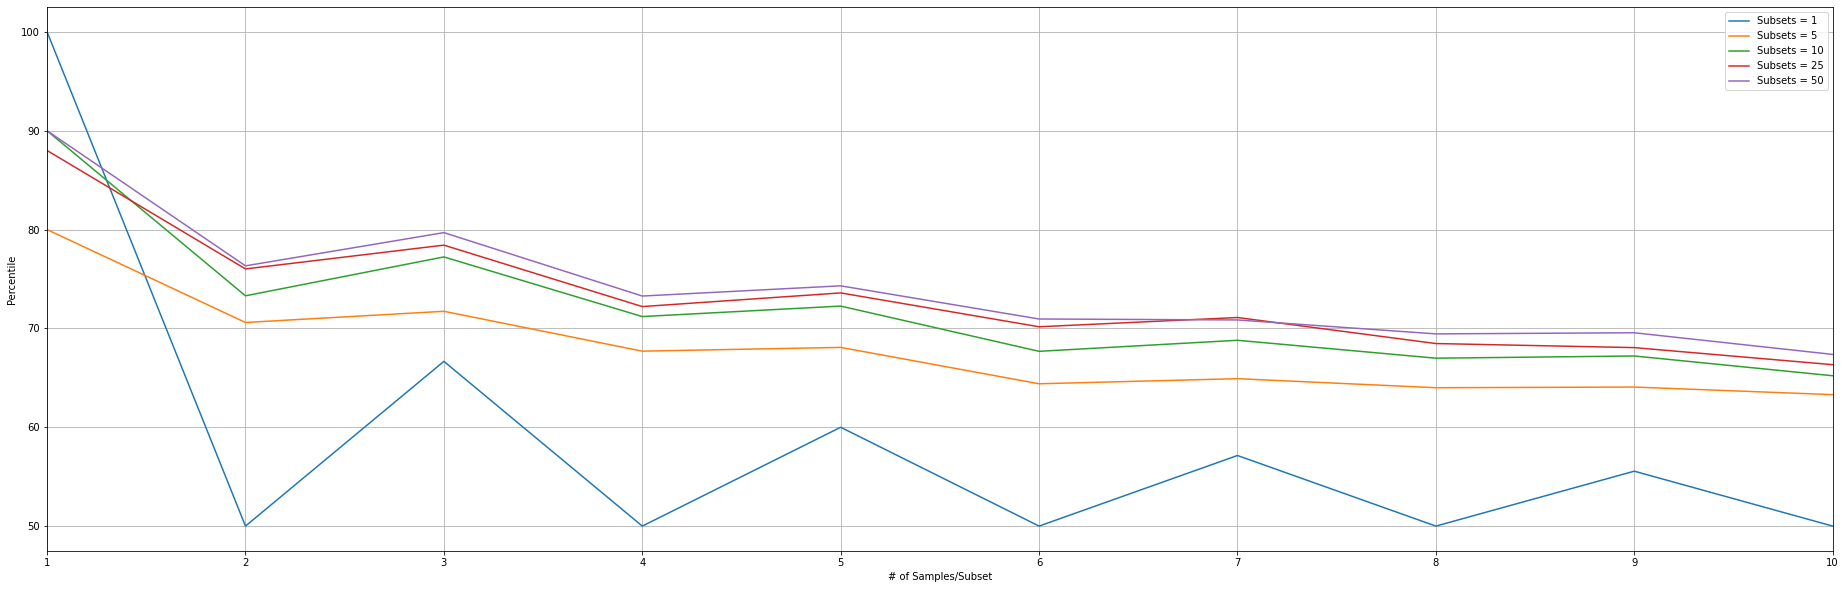

In [1056]:
fig, ax = plt.subplots()
fig.set_size_inches(32, 10)
ax.plot(num_samples_arr, pct_actual_1, label='Subsets = 1')
ax.plot(num_samples_arr, pct_actual_5, label='Subsets = 5')
ax.plot(num_samples_arr, pct_actual_10, label='Subsets = 10')
ax.plot(num_samples_arr, pct_actual_25, label='Subsets = 25')
ax.plot(num_samples_arr, pct_actual_50, label='Subsets = 50')
ax.set_xlim(1, 10)
ax.set_xlabel('# of Samples/Subset')
ax.set_ylabel('Percentile')
ax.grid()
_ = ax.legend()